In [67]:
import pandas as pd 
import seaborn as sns
from  sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

In [68]:
df = pd.read_csv("loan_approval_data.csv")

In [69]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

# handling missing value

In [71]:
categorical_col = df.select_dtypes(include="object").columns
numerical_col = df.select_dtypes(include="number").columns

In [72]:
from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')


df[numerical_col] = num_imputer.fit_transform(df[numerical_col])
df[categorical_col] = cat_imputer.fit_transform(df[categorical_col])


In [73]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [74]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA - exploretry data enalysis


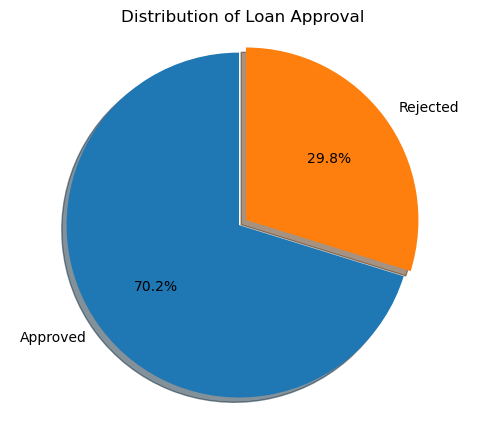

In [75]:
loan_counts = df["Loan_Approved"].value_counts()

plt.figure(figsize=(6, 5))

plt.pie(
    loan_counts,
    labels=["Approved", "Rejected"],
    autopct="%1.1f%%",
    startangle=90,
    explode=(0.05, 0),
    shadow=True
)

plt.title("Distribution of Loan Approval")
plt.axis("equal")  # Makes the pie chart circular

plt.show()

[Text(0, 0, '722'), Text(0, 0, '278')]

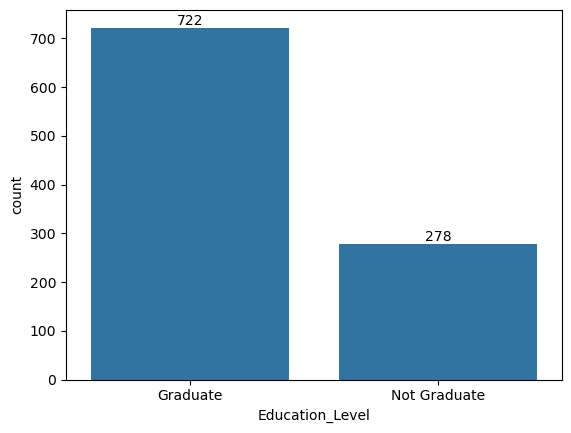

In [76]:
edu_bar = df["Education_Level"].value_counts()
ax = sns.barplot(edu_bar)
ax.bar_label(ax.containers[0])

[Text(0, 0, '621'), Text(0, 0, '379')]

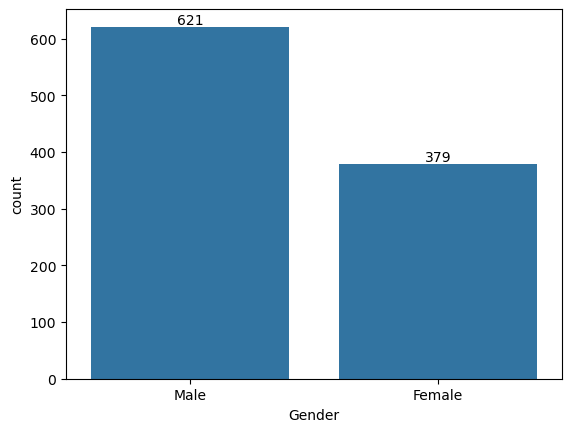

In [77]:
gen_bar = df["Gender"].value_counts()
ax = sns.barplot(gen_bar)
ax.bar_label(ax.containers[0])

[Text(0, 0, '517'), Text(0, 0, '294'), Text(0, 0, '189')]

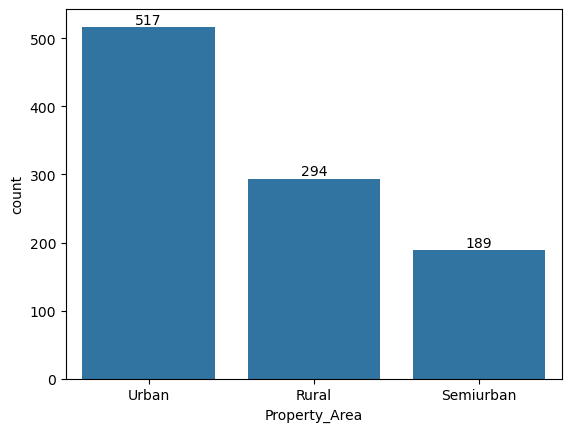

In [78]:
area_bar = df["Property_Area"].value_counts()
ax = sns.barplot(area_bar)
ax.bar_label(ax.containers[0])

[Text(0, 0, '252'),
 Text(0, 0, '199'),
 Text(0, 0, '190'),
 Text(0, 0, '181'),
 Text(0, 0, '178')]

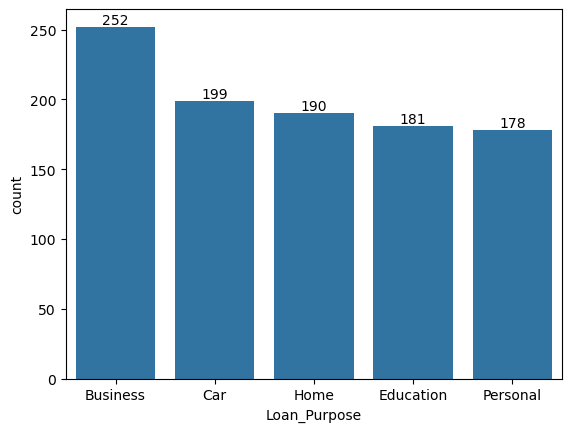

In [79]:
purpose_bar = df["Loan_Purpose"].value_counts()
ax = sns.barplot(purpose_bar)
ax.bar_label(ax.containers[0])

[Text(0, 0, '422'),
 Text(0, 0, '202'),
 Text(0, 0, '144'),
 Text(0, 0, '135'),
 Text(0, 0, '97')]

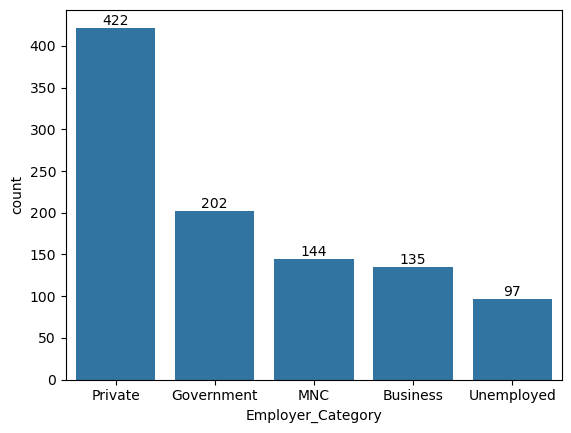

In [80]:
category_bar = df["Employer_Category"].value_counts()
ax = sns.barplot(category_bar)
ax.bar_label(ax.containers[0])

In [81]:
# analyze income

<Axes: xlabel='Applicant_Income', ylabel='Count'>

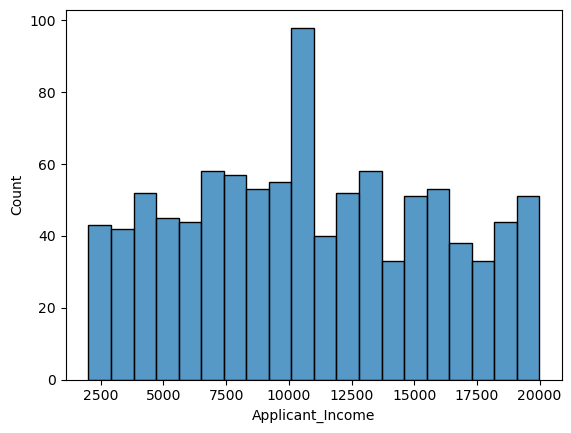

In [82]:
sns.histplot(
    data=df,
    x = "Applicant_Income",
    bins=20
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

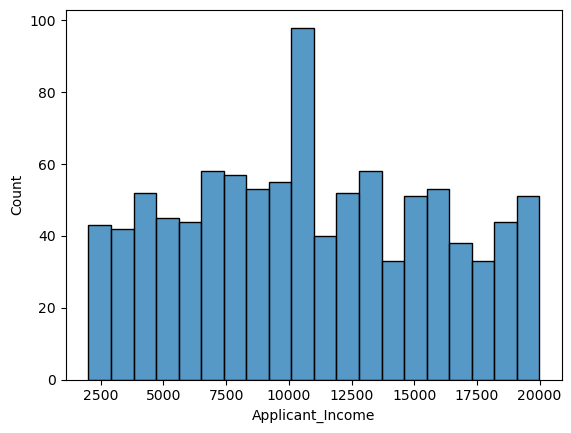

In [83]:
sns.histplot(
    data=df,
    x = "Applicant_Income",
    bins=20
)

In [84]:
# outerlier - box plot


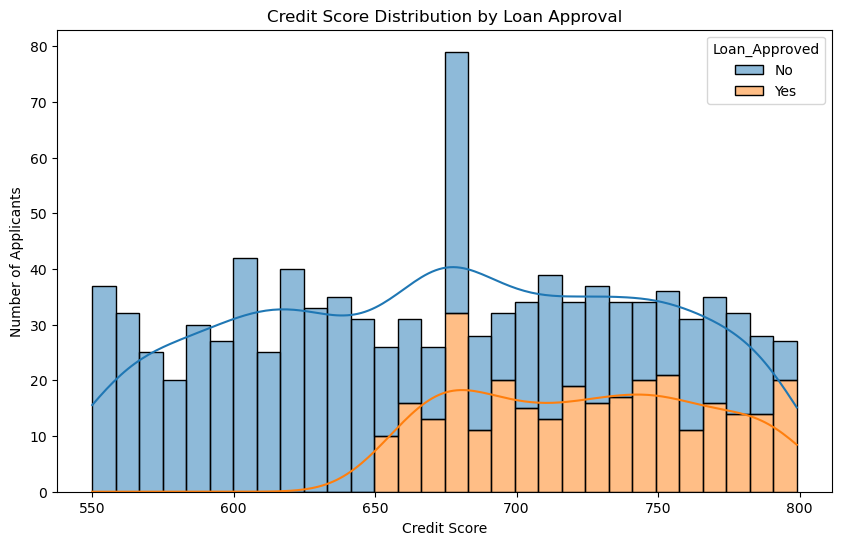

In [85]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=30,
    kde=True,
    multiple="stack"
)

plt.title("Credit Score Distribution by Loan Approval")
plt.xlabel("Credit Score")
plt.ylabel("Number of Applicants")

plt.show()

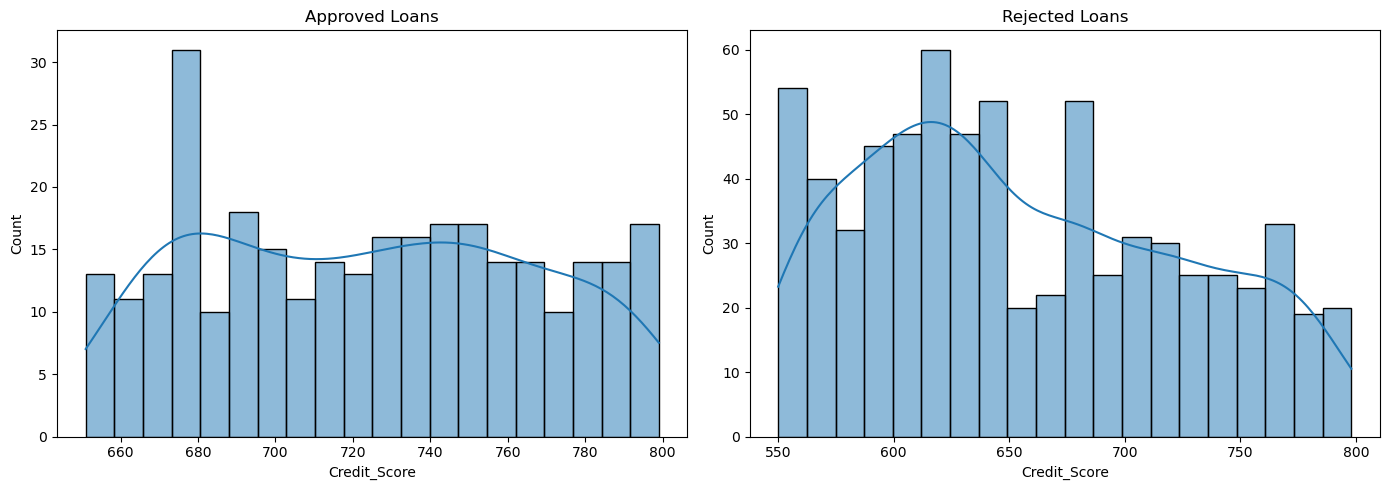

In [86]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Approved Loans
sns.histplot(
    data=df[df["Loan_Approved"] == "Yes"],
    x="Credit_Score",
    bins=20,
    kde=True,
    ax=ax[0]
)
ax[0].set_title("Approved Loans")

# Rejected Loans
sns.histplot(
    data=df[df["Loan_Approved"] == "No"],
    x="Credit_Score",
    bins=20,
    kde=True,
    ax=ax[1]
)
ax[1].set_title("Rejected Loans")

plt.tight_layout()
plt.show()

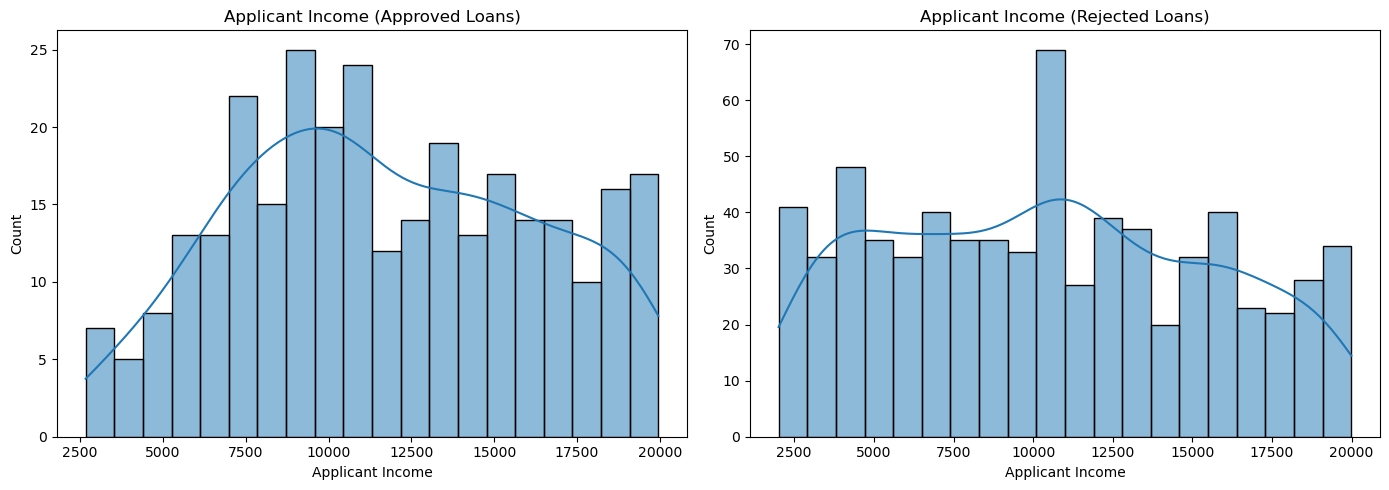

In [87]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Approved Loans
sns.histplot(
    data=df[df["Loan_Approved"] == "Yes"],
    x="Applicant_Income",
    bins=20,
    kde=True,
    ax=ax[0]
)
ax[0].set_title("Applicant Income (Approved Loans)")
ax[0].set_xlabel("Applicant Income")

# Rejected Loans
sns.histplot(
    data=df[df["Loan_Approved"] == "No"],
    x="Applicant_Income",
    bins=20,
    kde=True,
    ax=ax[1]
)
ax[1].set_title("Applicant Income (Rejected Loans)")
ax[1].set_xlabel("Applicant Income")

plt.tight_layout()
plt.show()

In [88]:
#remove applicant_id
df=df.drop("Applicant_ID", axis=1)

In [89]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# ENCODING 
